# pyTelops Showcase

Demonstrates the full workflow of the pyTelops driver for Telops FAST M3k thermal cameras:

1. Discovery & connection
2. Camera configuration
3. Live streaming
4. Buffer recording (5s at 2000 fps = 10,000 frames)
5. Buffer download
6. Viewing saved images

In [1]:
# Firewall: allow inbound UDP for this python.exe (needed for GVSP streaming)
# Run once â€” requires admin. If already done, this cell is a no-op.
import sys, subprocess
exe = sys.executable
rule_name = "pyTelops-GVSP"

result = subprocess.run(
    ["netsh", "advfirewall", "firewall", "show", "rule", f"name={rule_name}"],
    capture_output=True, text=True)

if "No rules match" in result.stderr or result.returncode != 0:
    print(f"Adding firewall rule for: {exe}")
    r = subprocess.run(
        ["netsh", "advfirewall", "firewall", "add", "rule",
         f"name={rule_name}", "dir=in", "action=allow",
         "protocol=UDP", f"program={exe}"],
        capture_output=True, text=True)
    print("Firewall rule added." if r.returncode == 0
          else f"Failed (need admin?): {r.stderr.strip()}")
else:
    print(f"Firewall rule '{rule_name}' already exists.")

Adding firewall rule for: c:\Users\jasas\Work\OpenSource\OpenEOL\openEOL_venv\Scripts\python.exe
Failed (need admin?): 


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time

from pyTelops import Camera, discover

## 1. Discovery

In [3]:
cameras = discover()
for c in cameras:
    print(f"{c['manufacturer']} {c['model']} at {c['ip']}")
    print(f"  Serial: {c.get('serial', '?')}, Version: {c.get('device_version', '?')}")

Telops Inc. TS-IR at 169.254.250.2
  Serial: , Version:  (02.05.27)


## 2. Connect

In [4]:
cam = Camera()
cam.connect()
print(cam)
print(cam.info)

Discovered: Telops Inc. TS-IR at 169.254.250.2
Camera(169.254.250.2, connected)
{'ip': '169.254.250.2', 'width': 320, 'height': 258, 'exposure_us': 30.0, 'exposure_auto': 'OFF', 'frame_rate_hz': 2000.0, 'calibration': 'RT', 'trigger_mode': 'OFF', 'power_state': 'ON', 'temperature_c': 0.0, 'buffer_mode': 'ON'}


## 3. Configure camera

In [5]:
cam.frame_rate = 2000.0
cam.exposure = 30.0       # microseconds (must be < 1/fps = 500 us)
cam.calibration_mode = "RT"

print(f"Frame rate:  {cam.frame_rate:.0f} Hz")
print(f"Exposure:    {cam.exposure:.1f} us")
print(f"Calibration: {cam.calibration_mode.name}")
print(f"Resolution:  {cam.resolution}")

Frame rate:  2000 Hz
Exposure:    30.0 us
Calibration: RT
Resolution:  (320, 258)


## 4. Grab a frame

Single frame via live streaming. Headers are stripped automatically.

Shape: (256, 320), dtype: uint16


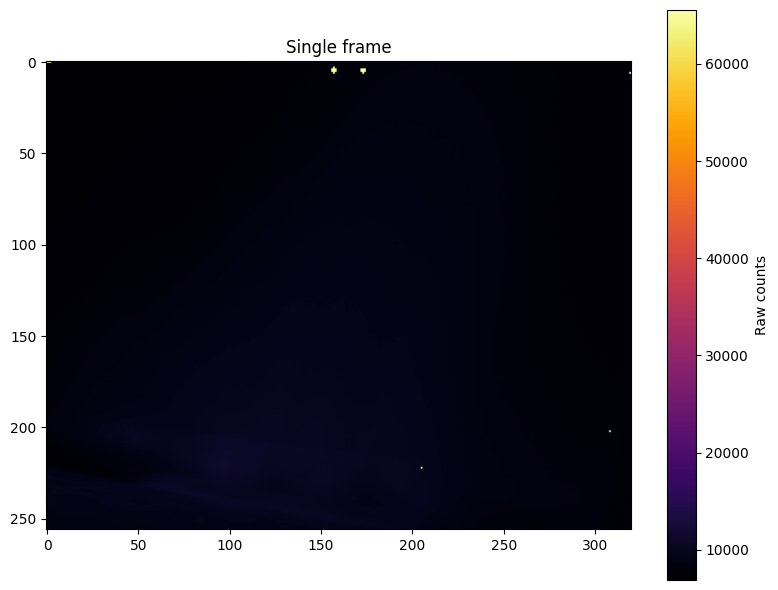

In [6]:
frame = cam.grab()
print(f"Shape: {frame.shape}, dtype: {frame.dtype}")

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(frame, cmap='inferno')
ax.set_title('Single frame')
plt.colorbar(im, ax=ax, label='Raw counts')
plt.tight_layout()
plt.show()

## 5. Live viewer (interactive)

Opens a Tkinter window with real-time thermal display and colormap selector.
Close the window to continue.

In [7]:
# Uncomment to launch live viewer (blocks until window is closed)
# cam.live_view(colormap='inferno', scale=2)

## 6. Configure buffer

The camera has a 16 GB internal ring buffer that records at full sensor speed
(up to 3100 fps), independent of the Ethernet link.

The buffer must be partitioned into fixed-size sequence slots before recording.

In [8]:
DURATION = 5.0   # seconds
FPS = 2000       # frames per second
N_FRAMES = int(DURATION * FPS)

cam.buffer_configure(
    n_sequences=1,
    frames_per_seq=N_FRAMES,
    moi_source="software",
)

print(f"Configured: {N_FRAMES} frames ({DURATION}s at {FPS} fps)")
print(f"Buffer: {cam.buffer_info()}")

Configured: 10000 frames (5.0s at 2000 fps)
Buffer: {'status': 'IDLE', 'n_sequences': 1, 'recorded': [0], 'total_bytes': 17179869184, 'free_bytes': 17179869184}


## 7. Record to buffer

One call: arms the camera, fires software MOI, waits for recording to complete.

In [9]:
cam.buffer_record(timeout=30.0);

Arming... Recording... Done (10000 frames)


## 8. Download from buffer

Downloads at max speed (~670 fps / 111 MB/s with default settings).
Headers are stripped automatically.

In [10]:
t0 = time.monotonic()
data = cam.buffer_download(sequence=0)
elapsed = time.monotonic() - t0

print(f"Shape: {data.shape}, dtype: {data.dtype}")
print(f"Time: {elapsed:.1f}s")
print(f"Speed: {data.shape[0] / elapsed:.0f} fps, "
      f"{data.nbytes / elapsed / 1e6:.1f} MB/s")

ModuleNotFoundError: No module named 'tqdm'

In [ ]:
# Save to disk
np.save('measurement_2000fps_5s.npy', data)
print(f"Saved: measurement_2000fps_5s.npy ({data.nbytes / 1e6:.0f} MB)")

In [ ]:
# Clean up buffer
cam.buffer_clear()

## 9. View recorded images

In [11]:
n, h, w = data.shape
print(f"{n} frames, {h}x{w} pixels, {n / FPS:.2f}s at {FPS} fps")

10000 frames, 256x320 pixels, 5.00s at 2000 fps


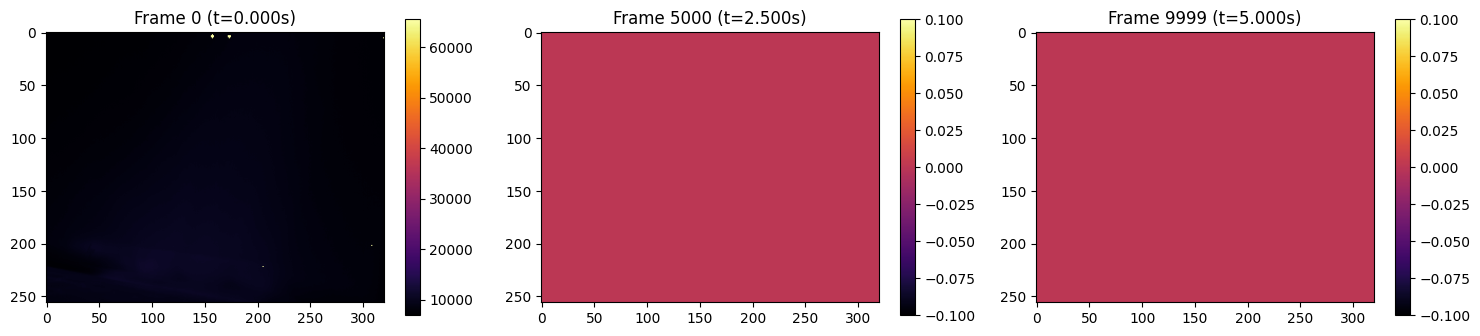

In [12]:
# First, middle, and last frame
indices = [0, n // 2, n - 1]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, idx in zip(axes, indices):
    im = ax.imshow(data[idx], cmap='inferno')
    ax.set_title(f'Frame {idx} (t={idx/FPS:.3f}s)')
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()

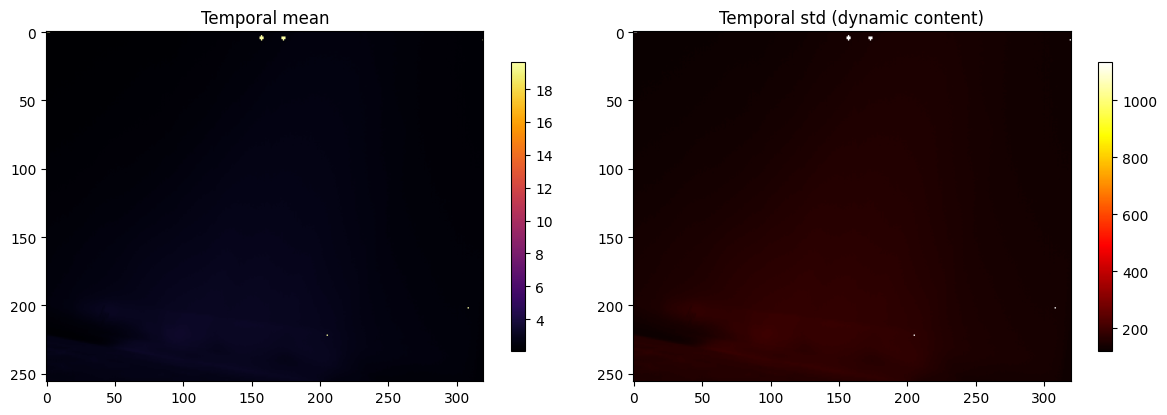

In [13]:
# Temporal mean and standard deviation
mean_img = data.mean(axis=0)
std_img = data.std(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im0 = axes[0].imshow(mean_img, cmap='inferno')
axes[0].set_title('Temporal mean')
plt.colorbar(im0, ax=axes[0], shrink=0.8)

im1 = axes[1].imshow(std_img, cmap='hot')
axes[1].set_title('Temporal std (dynamic content)')
plt.colorbar(im1, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.show()

In [ ]:
# Center pixel time series
py, px = h // 2, w // 2
t = np.arange(n) / FPS

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t, data[:, py, px], linewidth=0.5)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Raw counts')
ax.set_title(f'Center pixel ({px}, {py}) time series')
ax.set_xlim(0, t[-1])
plt.tight_layout()
plt.show()

## 10. Disconnect

In [ ]:
cam.disconnect()
print(f"State: {cam.state}")